# Impact Split Explainer

This notebook documents the story behind the math in `impact-split`: why it was built, how its formulas evolved, and how those formulas map to what the fitted tree actually shows.

## Prerequisites

- Python `3.13.x`
- `python -m pip install -e .`
- Run from the project environment where `impact_split` is importable

## Reproducibility Protocol

- This notebook is deterministic by design: it uses synthetic data only and seeds randomness with `np.random.default_rng(42)`.
- There is no external data/API dependency in this notebook.
- For reproducible outputs, use **Kernel -> Restart & Run All** and run cells in order.
- Compare reruns using the `repro_fingerprint` dictionary printed in the dedicated check cell.

Flow of this notebook:

1. The business paradox that average-purity trees miss
2. The three-act mathematical design (`delta`, gain, dual materiality)
3. A toy scenario with a documented synthetic DGP (planted category interactions, noise, observed outcome)
4. What to inspect in the generated tree and segments
5. How parameter choices change what we see

If you only need a high-level summary, use `README.md`. This notebook is the deeper walkthrough.

## 1) Problem Framing: Why This Needed a New Tree

Most classic trees (CART/C4.5 family) were designed to optimize variance and average purity. That is mathematically coherent, but for additive business KPIs it can be misleading.

A simple paradox:

- Segment A: 2 users x -5,000 average = -10,000 total
- Segment B: 10,000 users x -40 average = -400,000 total

Average-first trees can chase Segment A because it is "purer" by rate, while business decisions should often prioritize Segment B because it dominates total impact.

`impact-split` was created to optimize for additive totals directly, not average purity.

> Guiding question: which segments hold the most positive or negative mathematical material in absolute business terms?

## 2) The Three-Act Mathematical Design

The formulas below are the core design choices behind `impact-split`.

### Act I: Local Sieve (`delta`)

**Problem:** binary splits force categories into good/bad buckets and hide the baseline. We need Positive / Neutral / Negative routing.

At each node:

$$
V_{node} = \sum_{j=1}^{N_{node}} |y_j|
$$

$$
\delta = V_{node} \times \text{delta\_pct}
$$

For each category in feature $X_i$:

$$
S_{cat} = \sum_{y \in cat} y
$$

Routing rule:

- Positive if $S_{cat} > \delta$
- Negative if $S_{cat} < -\delta$
- Neutral otherwise

Why this matters: the neutral band auto-scales with local node volume, so the tree behaves like a zoom lens. Large nodes ignore tiny swings; deeper nodes can detect finer impacts.

#### DGP example (Act I)

In the synthetic run below, we compute Act I directly from `y_observed` at the root:

- $V_{node}$ and $\delta$ are computed in the **Act I actual-data cell** in Section 3.
- Category-level $S_{cat}$ values are then labeled Positive / Neutral / Negative by the same threshold rule.

Read this as: categories that clear $\pm\delta$ are material at this node; everything else remains in the neutral baseline branch.

**Implementation detail:** current splitter logic applies the scaled rule $\delta = V_{node} \times \text{delta\_pct}$ at every depth, including the root.

### Act II: Gain Metric (Category-Averaged Impact Divergence)

**Problem:** after ternary routing, we need a split score that rewards material impact but resists high-cardinality overfit.

Final score:

$$
Gain(X_i) = \frac{|S_P|}{k_P} + \frac{|S_N|}{k_N}
$$

Where $S_P, S_N$ are outer-branch sums and $k_P, k_N$ are category counts per outer branch.

Why this matters: the score balances volume and density, favoring features that isolate large positive/negative totals in fewer actionable categories.

#### DGP example (Act II)

In Section 3, the **Act II actual-data cell** computes this score for each feature from the same root-node synthetic sample:

- it derives $S_P, k_P, S_N, k_N$ from the Act I routing,
- then evaluates `Gain(X_i)` per feature,
- and ranks features by the resulting value.

So the winning feature is not hypothetical: it is the one that actually concentrates signed totals most strongly in this generated dataset.

### Act III: Global Kill Switch (Dual Materiality)

**Problem:** as $\delta$ shrinks down the tree, tiny local noise can eventually look important unless we stop by global business relevance.

Define global positive/negative maxima once:

$$
V_{global\_P} = \sum_{y_i > 0} y_i,
\quad
V_{global\_N} = \sum_{y_i < 0} |y_i|
$$

At each node:

$$
S_{node\_P} = \sum_{y_i \in node, y_i > 0} y_i,
\quad
S_{node\_N} = \sum_{y_i \in node, y_i < 0} |y_i|
$$

Stop if both sides are immaterial:

$$
\left(\frac{S_{node\_P}}{V_{global\_P}} \le \theta_{stop}\right)
\quad \text{AND} \quad
\left(\frac{S_{node\_N}}{V_{global\_N}} \le \theta_{stop}\right)
$$

with $\theta_{stop} = \text{min\_global\_impact\_pct}$.

Why this matters: positive mass is graded against the global positive pool, and negative mass against the global negative pool, avoiding net-sum distortions.

#### DGP example (Act III)

In Section 3, the **Act III actual-data cell** computes dual materiality from the same run:

- global pools $V_{global\_P}, V_{global\_N}$ from `y_observed`,
- node-level signed mass $S_{node\_P}, S_{node\_N}$ for a concrete child node,
- and the stop decision using `theta_stop = min_global_impact_pct`.

This directly answers the practical question: for this actual synthetic node, do both signed sides fall below the global materiality threshold?

Parameter mapping used later in code:

- `delta_pct` controls local sieve width at each node
- `min_global_impact_pct` sets the dual materiality threshold

In [1]:
import numpy as np
import pandas as pd

from impact_split import ImpactSplitter

2026-03-29 15:02:11.156 | INFO     | impact_split.config:<module>:11 - PROJ_ROOT path is: /Users/juedimyroeugenio/Documents/Projects/impact-split


## 3) Synthetic data (DGP)

We simulate a **documented** data-generating process so we can compare *what we planted* with *what the tree finds autonomously*.

### Act I in the DGP: category routing intuition

The DGP plants explicit signed effects on category combinations (region/channel/product), so category sums naturally separate into positive, negative, and near-neutral groups under the local $\delta$ rule.

### Act II in the DGP: why the selected feature wins

Because the planted effects are concentrated in specific category combinations, some features produce outer branches with larger absolute totals per category, which is exactly what the gain metric rewards.

### Act III in the DGP: when splitting should stop

As depth increases, local thresholds get tighter. The dual-materiality stop prevents the model from chasing tiny residual pockets once both positive and negative node mass are globally immaterial.

The next cells build and run the full synthetic setup:

- **`y_expected`** — row-level contribution from **explicit categorical rules** (two-way and three-way combinations of region, channel, and product). There is **no** separate marginal effect (e.g. region-only bias): the only systematic signal lives in these interaction masks.
- **`epsilon`** — iid noise around each row.

We **fit the tree on `y_observed = y_expected + epsilon`** only (one observed outcome per row, like real data).

The notebook lists each planted rule in `planted_rules_df` with row counts and totals on each rule’s **mask** before fitting. Rule masks are **pairwise disjoint**, so each row receives at most one planted increment and slice totals match `n × planted_increment` for that rule.

We pass **`X_df`** into `ImpactSplitter`: the library factorizes each column to integer codes and stores **`model.feature_names_in_`** and **`model.category_maps_`** for decoding. **`plot_tree`** shows the current segment (`all data` or `feature=categories`) on every node, plus `split on <feature>` on internal nodes; full cumulative filters stay in segment **`path`** strings, using column names (`region`, `channel`, `product`) and category labels instead of `f0` / `f1` / `f2`.

In [2]:
# Build a toy scenario for illustration (not a claim about real data)
rng = np.random.default_rng(42)
n = 5000

regions = np.array(["NCR", "Luzon", "Visayas", "Mindanao"])
channels = np.array(["Direct", "Partner", "Online"])
products = np.array(["A", "B", "C"])

X_df = pd.DataFrame(
    {
        "region": rng.choice(regions, size=n, p=[0.35, 0.3, 0.2, 0.15]),
        "channel": rng.choice(channels, size=n, p=[0.25, 0.35, 0.4]),
        "product": rng.choice(products, size=n, p=[0.4, 0.35, 0.25]),
    }
)

# Planted rules: only category *combinations* drive the target (no region-only bias).
# Masks are pairwise disjoint so each row gets at most one structural increment.
rule_specs = [
    ("NCR × Direct", (X_df["region"] == "NCR") & (X_df["channel"] == "Direct"), 120.0),
    ("Mindanao × Partner × {A,B}", (X_df["region"] == "Mindanao") & (X_df["channel"] == "Partner") & (X_df["product"].isin(["A", "B"])), -95.0),
    ("Luzon × Online × C", (X_df["region"] == "Luzon") & (X_df["channel"] == "Online") & (X_df["product"] == "C"), 35.0),
    ("Luzon × Partner", (X_df["region"] == "Luzon") & (X_df["channel"] == "Partner"), 60.0),
    ("Visayas × Online", (X_df["region"] == "Visayas") & (X_df["channel"] == "Online"), -45.0),
    ("Luzon × Online × A (3-way)", (X_df["region"] == "Luzon") & (X_df["channel"] == "Online") & (X_df["product"] == "A"), 50.0),
]

y_expected = np.zeros(n, dtype=np.float64)
for _label, mask, effect in rule_specs:
    y_expected += np.where(mask, effect, 0.0)

# Noise: tuned so planted structure remains visible under default splitter settings.
epsilon = rng.normal(loc=0, scale=22, size=n)
y_observed = y_expected + epsilon

feature_names = ["region", "channel", "product"]

# Ground truth: one row per planted rule (before fitting the tree).
planted_rows = []
for label, mask, effect in rule_specs:
    m = mask.to_numpy() if hasattr(mask, "to_numpy") else np.asarray(mask)
    planted_rows.append(
        {
            "rule": label,
            "planted_increment": effect,
            "n": int(m.sum()),
            "mean_y_on_slice": float(y_expected[m].mean()),
            "sum_y_expected": float(y_expected[m].sum()),
            "sum_y_observed": float(y_observed[m].sum()),
        }
    )
planted_rules_df = pd.DataFrame(planted_rows)
planted_rules_df["abs_sum_expected"] = planted_rules_df["sum_y_expected"].abs()
# Rule masks are disjoint in this toy DGP, so each row contributes to at most one planted rule.
planted_rules_df.sort_values("abs_sum_expected", ascending=False)

,rule,planted_increment,n,mean_y_on_slice,sum_y_expected,sum_y_observed,abs_sum_expected
0,NCR × Direct,120.0,470,120.0,56400.0,56283.622362,56400.0
3,Luzon × Partner,60.0,531,60.0,31860.0,32142.696244,31860.0
1,"Mindanao × Partner × {A,B}",-95.0,199,-95.0,-18905.0,-18194.264010,18905.0
4,Visayas × Online,-45.0,405,-45.0,-18225.0,-17466.584197,18225.0
5,Luzon × Online × A (3-way),50.0,232,50.0,11600.0,11300.287624,11600.0
2,Luzon × Online × C,35.0,136,35.0,4760.0,4979.682047,4760.0


**Actual-data check for Act I (root node):** the cell below computes `V_node`, `delta`, and category-level `S_cat`/`route` from this synthetic run (`y_observed`, baseline `delta_pct = 0.05`). Read it as a direct threshold test: each category is labeled by whether `S_cat` is above `+delta`, below `-delta`, or inside the neutral band.

In [3]:
# Act I (actual data): root-node local sieve using observed outcome
act_delta_pct = 0.05
V_node = float(np.abs(y_observed).sum())
delta = float(V_node * act_delta_pct)

act1_rows = []
for feat in feature_names:
    for cat, grp in X_df.groupby(feat, observed=False):
        S_cat = float(y_observed[grp.index].sum())
        route = "Positive" if S_cat > delta else ("Negative" if S_cat < -delta else "Neutral")
        act1_rows.append(
            {
                "feature": feat,
                "category": cat,
                "S_cat": S_cat,
                "route": route,
            }
        )

act1_df = pd.DataFrame(act1_rows).sort_values(["feature", "S_cat"], ascending=[True, False])
print(f"Act I baseline (actual data): V_node={V_node:,.2f}, delta={delta:,.2f}")
act1_df

Act I baseline (actual data): V_node=194,690.70, delta=9,734.54


,feature,category,S_cat,route
4,channel,Direct,56637.071294,Positive
6,channel,Partner,15173.316141,Positive
5,channel,Online,-584.128638,Neutral
7,product,A,31431.398799,Positive
9,product,C,24424.881910,Positive
8,product,B,15369.978088,Positive
2,region,NCR,57833.445762,Positive
0,region,Luzon,48375.722987,Positive
3,region,Visayas,-16930.189748,Negative
1,region,Mindanao,-18052.720204,Negative


Interpretation: use the printed line `V_node=...` and `delta=...` as the active cutoffs for this run, then read the table row-by-row. In this output, categories with large positive `S_cat` (for example `channel=Direct` and `region=NCR`) are routed `Positive`, categories with sufficiently negative `S_cat` (for example `region=Visayas` and `region=Mindanao`) are routed `Negative`, and near-zero sums (for example `channel=Online`) stay `Neutral`. That is the concrete Act I routing that feeds Act II scoring.

**Actual-data check for Act II (root-node gain):** the next cell computes `S_P`, `k_P`, `S_N`, `k_N`, and `Gain(X_i)` for each candidate feature from the same synthetic run. This is the exact score table used to choose the root split feature.

In [4]:
# Act II (actual data): category-averaged impact divergence at root

def compute_gain_for_feature(df, feature, y, delta_value):
    cat_sums = df.groupby(feature, observed=False).apply(lambda g: float(y[g.index].sum()))
    pos = cat_sums[cat_sums > delta_value]
    neg = cat_sums[cat_sums < -delta_value]

    S_P = float(pos.sum()) if len(pos) else 0.0
    S_N = float(neg.sum()) if len(neg) else 0.0
    k_P = int(len(pos))
    k_N = int(len(neg))

    gain = (abs(S_P) / k_P if k_P else 0.0) + (abs(S_N) / k_N if k_N else 0.0)
    return {
        "feature": feature,
        "S_P": S_P,
        "k_P": k_P,
        "S_N": S_N,
        "k_N": k_N,
        "Gain(X_i)": gain,
    }

act2_df = pd.DataFrame(
    [compute_gain_for_feature(X_df, feat, y_observed, delta) for feat in feature_names]
).sort_values("Gain(X_i)", ascending=False)

act2_df

,feature,S_P,k_P,S_N,k_N,Gain(X_i)
0,region,106209.168749,2,-34982.909952,2,70596.039351
1,channel,71810.387435,2,0.000000,0,35905.193717
2,product,71226.258797,3,0.000000,0,23742.086266


Interpretation: sort by `Gain(X_i)` and inspect how each row got that score. In this run, `region` ranks first because it has material mass on both sides (`S_P` and `S_N`) with compact category counts (`k_P`, `k_N`), while `channel` and `product` are mostly positive-side concentration at the root. So the table numerically confirms why `region` is the strongest split candidate here.

**Actual-data check for Act III (dual materiality):** the next cell computes `V_global_P`, `V_global_N`, node-level `S_node_P`, `S_node_N`, then evaluates `ratio_P`, `ratio_N`, and `stop` for a concrete child node derived from the strongest root feature.

In [5]:
# Act III (actual data): dual-materiality stop decision on a concrete node
act_theta_stop = 0.01

V_global_P = float(y_observed[y_observed > 0].sum())
V_global_N = float(np.abs(y_observed[y_observed < 0]).sum())

best_feature = act2_df.iloc[0]["feature"]
feature_sums = X_df.groupby(best_feature, observed=False).apply(lambda g: float(y_observed[g.index].sum()))
pos_categories = feature_sums[feature_sums > delta].index.tolist()

if pos_categories:
    node_mask = X_df[best_feature].isin(pos_categories)
    node_label = f"{best_feature} in {pos_categories}"
else:
    # fallback (rare): use the category with largest positive sum
    fallback_cat = feature_sums.idxmax()
    node_mask = X_df[best_feature] == fallback_cat
    node_label = f"{best_feature} == {fallback_cat}"

node_values = y_observed[node_mask.to_numpy()]
S_node_P = float(node_values[node_values > 0].sum())
S_node_N = float(np.abs(node_values[node_values < 0]).sum())

ratio_P = S_node_P / V_global_P if V_global_P else 0.0
ratio_N = S_node_N / V_global_N if V_global_N else 0.0
stop_node = (ratio_P <= act_theta_stop) and (ratio_N <= act_theta_stop)

pd.DataFrame(
    [
        {
            "node_example": node_label,
            "V_global_P": V_global_P,
            "V_global_N": V_global_N,
            "S_node_P": S_node_P,
            "S_node_N": S_node_N,
            "ratio_P": ratio_P,
            "ratio_N": ratio_N,
            "theta_stop": act_theta_stop,
            "stop": stop_node,
        }
    ]
)

,node_example,V_global_P,V_global_N,S_node_P,S_node_N,ratio_P,ratio_N,theta_stop,stop
0,"region in ['Luzon', 'NCR']",132958.479861,61732.221064,122582.198452,16373.029703,0.921958,0.265227,0.01,False


Interpretation: check `ratio_P` and `ratio_N` against `theta_stop` in the row. In this run, both ratios are well above the threshold, so `stop=False` and the branch remains globally material. Act III would only stop recursion when **both** ratios fall at or below `theta_stop` for a node.

In [6]:
# 4) Fit one baseline configuration for exploration (observed outcome only)
y_fit = y_observed.astype(np.float64, copy=False)

model = ImpactSplitter(
    delta_pct=0.05,
    min_global_impact_pct=0.01,
    max_depth=4,
)

model.fit(X_df, y_fit)

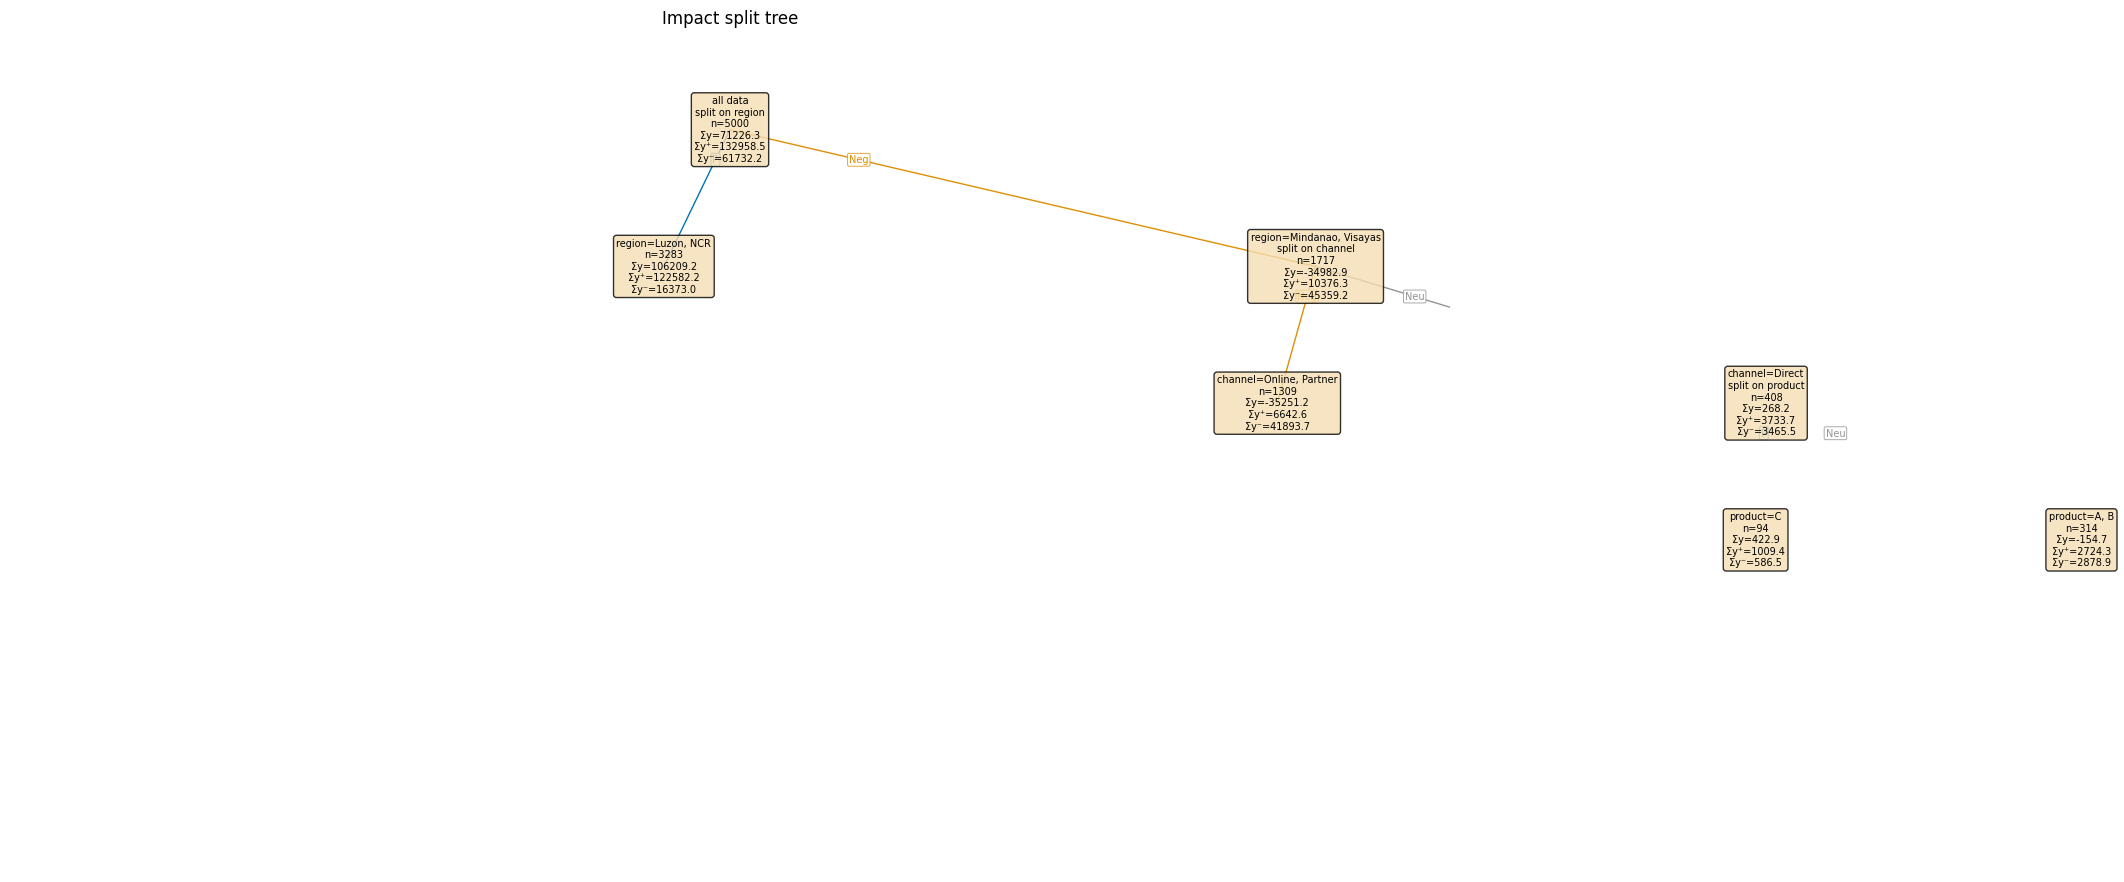

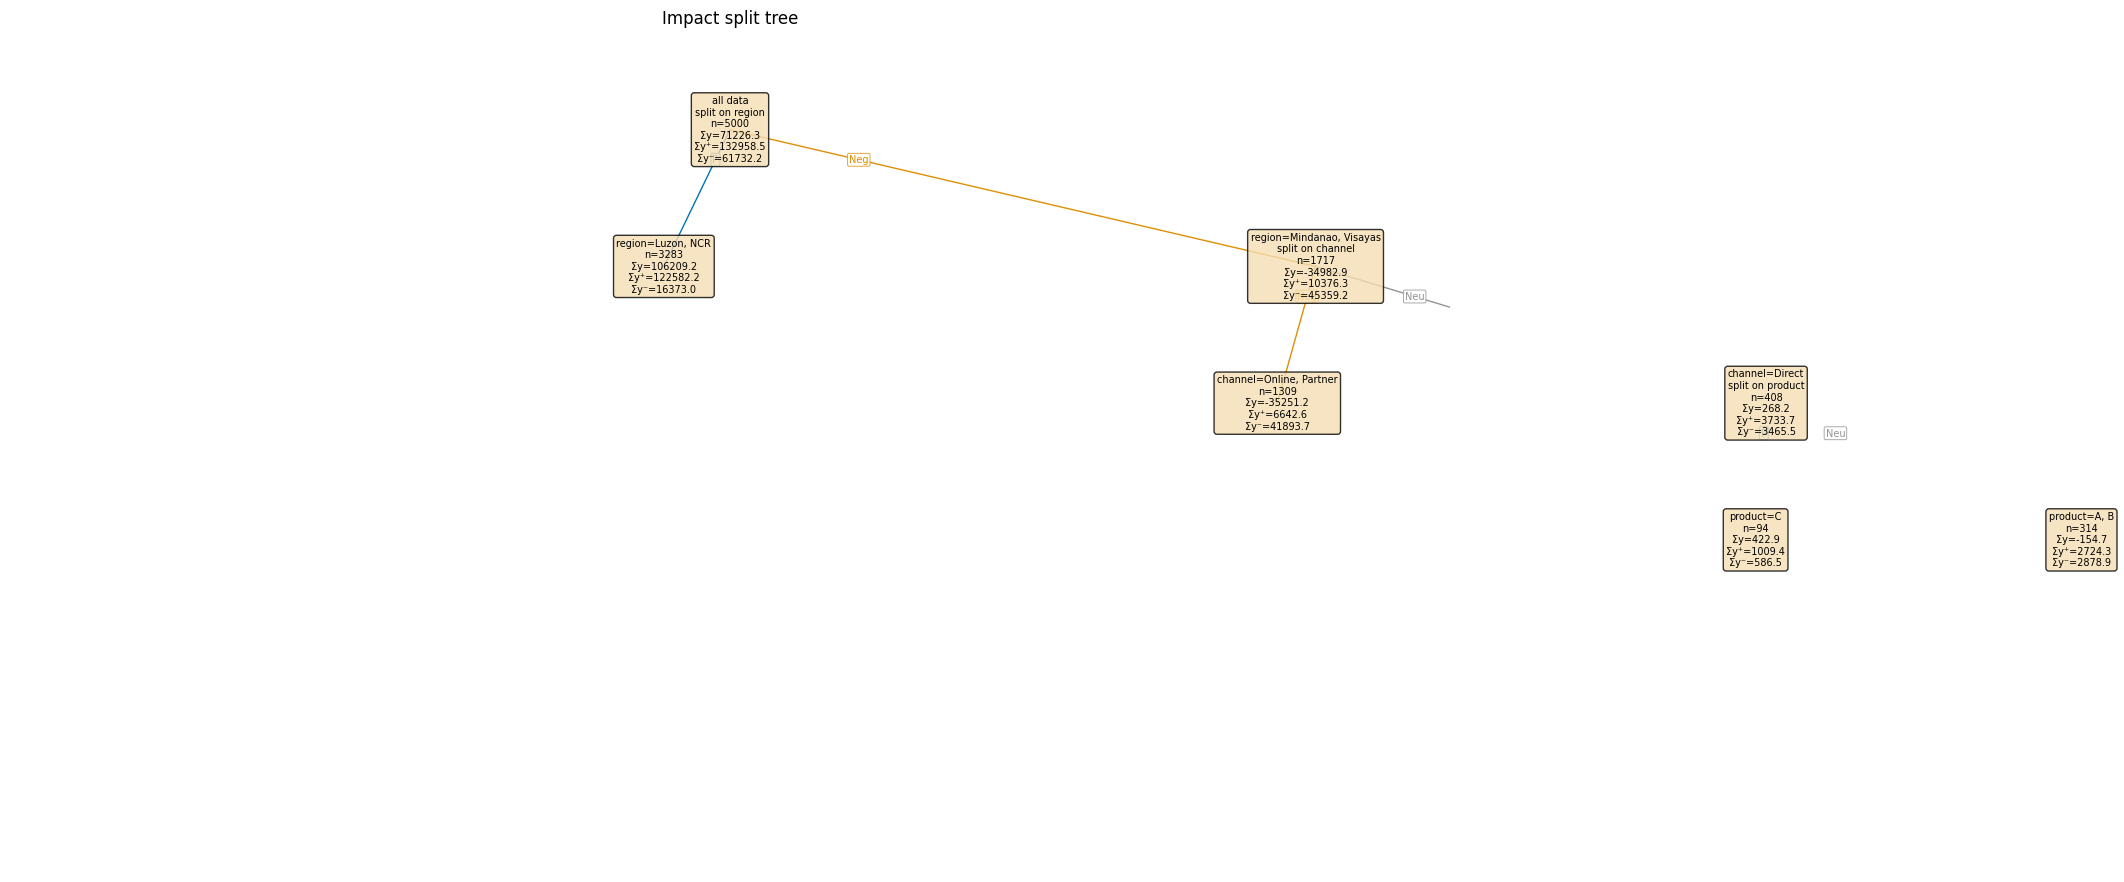

In [7]:
# Inspect the split structure produced by the baseline run.
model.plot_tree(figsize=(16, 10))

In [8]:
# Inspect top segments and compare them with the planted rules (ground truth before fit).
segments = model.get_impact_segments()

print(
    "Global sum(y_expected) =",
    float(y_expected.sum()),
    "| Global sum(y_observed) =",
    float(y_observed.sum()),
)
print("\nPlanted rules (structural totals on each mask, sorted by |sum_y_expected|):")
print(
    planted_rules_df.sort_values("abs_sum_expected", ascending=False)[
        ["rule", "planted_increment", "n", "mean_y_on_slice", "sum_y_expected", "sum_y_observed"]
    ].to_string(index=False)
)

top_rules = planted_rules_df.sort_values("abs_sum_expected", ascending=False).head(3)["rule"].tolist()
print("\nLargest planted rules by |structural total| (for eyeballing the tree):", top_rules)
print(
    "\nTop segments by |total_sum| use paths with feature names region, channel, product "
    "(positive/negative/neutral = category routing at each split)."
)

seg_by_abs = segments.assign(_abs=np.abs(segments["total_sum"])).sort_values(
    "_abs", ascending=False
).drop(columns=["_abs"])
seg_by_abs.head(15)

Global sum(y_expected) = 67490.0 | Global sum(y_observed) = 71226.25879712423

Planted rules (structural totals on each mask, sorted by |sum_y_expected|):
                      rule  planted_increment   n  mean_y_on_slice  sum_y_expected  sum_y_observed
              NCR × Direct              120.0 470            120.0         56400.0    56283.622362
           Luzon × Partner               60.0 531             60.0         31860.0    32142.696244
Mindanao × Partner × {A,B}              -95.0 199            -95.0        -18905.0   -18194.264010
          Visayas × Online              -45.0 405            -45.0        -18225.0   -17466.584197
Luzon × Online × A (3-way)               50.0 232             50.0         11600.0    11300.287624
        Luzon × Online × C               35.0 136             35.0          4760.0     4979.682047

Largest planted rules by |structural total| (for eyeballing the tree): ['NCR × Direct', 'Luzon × Partner', 'Mindanao × Partner × {A,B}']

Top segments 

,path,total_sum,n_samples,node_id
0,"root / region=Luzon, NCR",106209.168749,3283,node_1
1,"root / region=Mindanao, Visayas / channel=Onli...",-35251.158519,1309,node_3
2,"root / region=Mindanao, Visayas / channel=Dire...",422.907055,94,node_5
3,"root / region=Mindanao, Visayas / channel=Dire...",-154.658488,314,node_6


In [9]:
# Reproducibility check: compare this fingerprint across reruns.
seg_for_fp = segments.assign(_abs=np.abs(segments["total_sum"])).sort_values(
    "_abs", ascending=False
)

repro_fingerprint = {
    "seed": 42,
    "n_samples": int(n),
    "sum_y_expected": round(float(y_expected.sum()), 6),
    "sum_y_observed": round(float(y_observed.sum()), 6),
    "act1_delta": round(float(delta), 6),
    "top_segment_paths": seg_for_fp["path"].head(5).tolist(),
    "top_segment_totals": [round(float(v), 6) for v in seg_for_fp["total_sum"].head(5).tolist()],
}

repro_fingerprint

{'seed': 42,
 'n_samples': 5000,
 'sum_y_expected': 67490.0,
 'sum_y_observed': 71226.258797,
 'act1_delta': 9734.535046,
 'top_segment_paths': ['root / region=Luzon, NCR',
  'root / region=Mindanao, Visayas / channel=Online, Partner',
  'root / region=Mindanao, Visayas / channel=Direct / product=C',
  'root / region=Mindanao, Visayas / channel=Direct / product=A, B'],
 'top_segment_totals': [106209.168749, -35251.158519, 422.907055, -154.658488]}

### Reading the segments

Use this output in three passes:

1. **Global sanity check**: compare `Global sum(y_expected)` vs `Global sum(y_observed)` to confirm noise perturbs totals but preserves the planted signal scale.
2. **Rule anchors**: read `planted_rules_df` (sorted by `abs_sum_expected`) as the structural benchmark for what should dominate (`NCR × Direct`, `Luzon × Partner`, `Mindanao × Partner × {A,B}` in this run).
3. **Model output**: inspect top rows in `seg_by_abs` (`path`, `total_sum`) and check whether largest positive/negative leaves are directionally consistent with those benchmark rules.

The tree is fit on **`y_observed`**, so leaf `total_sum` values are not expected to match `y_expected` mask sums exactly; alignment should be assessed by sign, relative magnitude, and decoded path meaning. Paths and plots use column names and category values; inspect **`model.category_maps_`** if you need code-to-label maps.

## 5) Parameter Exploration

This section connects parameter choices to the printed top-3 segment table in each run.

We vary:

- `delta_pct` (local sieve width)
- `min_global_impact_pct` (global materiality stop)

How to read the output below:

- Compare each run's top `path` and `total_sum` rows directly.
- In this notebook's current results, the first two high-magnitude segments remain stable across all settings shown, which indicates robust dominant structure.
- The third segment changes between settings (for example, from a deeper `.../f2=positive` path to a shallower `.../f1=neutral` path), illustrating how stricter thresholds can collapse or reroute marginal branches.

Treat this section as a sensitivity check: stable top segments suggest strong signal; shifting lower-rank segments show where interpretation is parameter-dependent.

In [10]:
# Run a small comparison grid and review differences in top segments.
for delta_pct, min_global_impact_pct in [(0.03, 0.01), (0.05, 0.01), (0.08, 0.02)]:
    m = ImpactSplitter(
        delta_pct=delta_pct,
        min_global_impact_pct=min_global_impact_pct,
        max_depth=4,
    )
    m.fit(X_df, y_fit)
    top = m.get_impact_segments().head(3)
    print(f"delta_pct={delta_pct}, min_global_impact_pct={min_global_impact_pct}")
    print(top[["path", "total_sum"]] if {"path", "total_sum"}.issubset(top.columns) else top)
    print("-" * 80)

delta_pct=0.03, min_global_impact_pct=0.01
                                                path      total_sum
0                           root / region=Luzon, NCR  106209.168749
1  root / region=Mindanao, Visayas / channel=Onli...  -35251.158519
2  root / region=Mindanao, Visayas / channel=Dire...     422.907055
--------------------------------------------------------------------------------
delta_pct=0.05, min_global_impact_pct=0.01
                                                path      total_sum
0                           root / region=Luzon, NCR  106209.168749
1  root / region=Mindanao, Visayas / channel=Onli...  -35251.158519
2  root / region=Mindanao, Visayas / channel=Dire...     422.907055
--------------------------------------------------------------------------------
delta_pct=0.08, min_global_impact_pct=0.02
                                                path      total_sum
0                           root / region=Luzon, NCR  106209.168749
1  root / region=Mindanao, Vi

## 6) Optional interactive force-graph view

If you want an interactive, browser-native view of relationships between split segments, you can render a D3 force graph directly from Python and export it to standalone HTML.

The next cell is intentionally lightweight and can be adapted to your own segment graph construction.

In [11]:
from impact_split import interactive_force_graph

nodes = [
    {"id": "root", "label": "Root", "group": "all", "tooltip": "All data"},
    {"id": "positive", "label": "Positive", "group": "positive"},
    {"id": "neutral", "label": "Neutral", "group": "neutral"},
    {"id": "negative", "label": "Negative", "group": "negative"},
]
links = [
    {"source": "root", "target": "positive", "value": 3},
    {"source": "root", "target": "neutral", "value": 2},
    {"source": "root", "target": "negative", "value": 1},
]

def _on_selection(event: dict) -> None:
    print("selection:", event)

graph = interactive_force_graph(
    nodes=nodes,
    links=links,
    filter_keys=["group"],
    options={"width": 900, "height": 520, "charge_strength": -120},
    on_selection=_on_selection,
)
graph.show()
# graph.save_html("reports/figures/impact_split_force_graph.html")